# Topic Modelling

## DHSI — Introduction to Computational Text Analysis

This notebook walks through **topic modelling**, a way of discovering the themes that run through a collection of texts — without telling the computer in advance what to look for.

We'll go from the big picture down to the details, then build a model end-to-end. By the end of the notebook you'll be able to:

1. Explain *what* a topic model is and *why* it's useful
2. Prepare a corpus for topic modelling (preprocessing, vocabulary)
3. Train an LDA model and read the results
4. Interpret which documents are about which topics
5. Spot common pitfalls and know what to try next

## 1. What is topic modelling?

Suppose you have 200 novels, or 50 000 newspaper articles, or every philosophy paper published since 1950. You can't read all of them. But you'd like to know: **what are they about?**

Topic modelling is a family of statistical methods that answer this question by finding **patterns of word co-occurrence**. The intuition:

- Words about the same topic tend to appear in the same documents.
- *Ship*, *sea*, *captain*, *whale*, *harpoon* — when these cluster together, that's probably a topic about whaling.
- *Ring*, *wizard*, *elf*, *dragon*, *quest* — that's fantasy.

A **topic model** is a recipe for finding such clusters automatically. The output isn't a tidy label like "whaling" — the computer doesn't know what whaling is. Instead, each topic is just a **ranked list of words** that tend to occur together. The label is for you to add.

### LDA in one paragraph

We'll use **Latent Dirichlet Allocation (LDA)**, the classic algorithm from Blei, Ng & Jordan (2003). LDA assumes that every document is a **mixture of topics**, and every topic is a **distribution over words**. Given a corpus, it figures out which mixtures and distributions best explain what we see. *Latent* = hidden (the topics aren't labelled in advance), *Dirichlet* = the family of probability distributions it uses.

### What you'll need

A folder of plain-text files. One document per file. Pre-lemmatised is best (so *runs*, *running*, *ran* all become *run* and count as one word), but our corpus already has that done.

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
! pip install gensim



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import os
from toolbox_tm import (
    load_corpus,
    build_dictionary,
    fit_lda,
    top_words_per_topic,
    top_documents_per_topic,
    document_topic_heatmap,
)

INPUT_FOLDER = os.path.expanduser("~/DHSI_2026/A_Small_Collection_of_British_Fiction/lemmatized_corpus")

## 2. Loading the corpus

`load_corpus` reads every `.txt` file in a folder, tokenises it, and returns a dictionary mapping filenames to token lists.

Two important options:

- **`exclude_stop_words=True`** (default) drops common English function words (*the, of, and, ...*). For topic modelling you almost always want this — stop words appear in every document and don't distinguish topics. They would dominate every topic and tell you nothing useful.
- **`min_word_len=3`** (default) drops one- and two-letter tokens. These are usually noise: leftover *m*, *ll*, *re* from contractions, single letters from OCR errors, etc.

In [2]:
processed = load_corpus(INPUT_FOLDER)

# Quick look at what one document looks like after processing
first_doc = next(iter(processed))
print(f"\nFirst document: {first_doc}")
print(f"First 20 tokens: {processed[first_doc][:20]}")

Loaded 27 documents, 2,902,503 tokens total.

First document: ABronte_Agnes_lemmatized.txt
First 20 tokens: ['agnes', 'grey', 'chapter', 'ithe', 'parsonage', 'true', 'history', 'contain', 'instruction', 'though', 'treasure', 'may', 'hard', 'find', 'find', 'trivial', 'quantity', 'dry', 'shrivelled', 'kernel']


### Why stop word removal matters

If you skip it, every topic will have *the*, *of*, *and* at the top — which is a true statement about word frequency but useless for understanding *content*. Try it on a small corpus to see the difference. The first few topics often look like:

> Topic 0: the, of, and, to, a, in, that, is, was, ...

for every topic. Not informative.

## 3. Building the vocabulary

Even after stop words, the corpus has thousands of unique words. Many appear in only one document (proper names, typos, very rare vocabulary) — they can't help us connect documents into topics. And a few appear in nearly every document — they're effectively new stop words for *this corpus*.

`build_dictionary` filters both ends:

- **`min_df=2`** — keep only words appearing in at least 2 documents
- **`max_df=0.8`** — drop words appearing in more than 80% of documents

These defaults work for most literary corpora. For very small corpora (under 10 documents) try `min_df=1`. For very large ones (thousands of documents) try `min_df=5` or `min_df=10`.

In [3]:
dictionary = build_dictionary(processed, min_df=2, max_df=0.8)

Vocabulary: 95,466 unique words -> 28,955 after filtering
  Kept words appearing in at least 2 document(s) and at most 80% of 27 documents.


## 4. Fitting the LDA model

Now we actually train the topic model. The key parameter is **`num_topics`** — how many topics LDA should look for.

There's **no "correct" number of topics**. It depends on:

- The size of your corpus (more documents → more topics make sense)
- How diverse it is (a single-genre corpus needs fewer topics than a mixed one)
- What you want to *see* (broad themes vs fine-grained sub-themes)

A rough rule of thumb for a small literary corpus: **start with 5 to 15 topics**, look at the results, and adjust. We'll begin with 10.

The other parameter, **`passes`**, controls how many times LDA cycles through the corpus during training. More passes = better fit but slower. 10 to 20 is usually fine.

**Random seed.** LDA is stochastic — different runs give slightly different topics. We fix `random_state=42` for reproducibility, but feel free to try different seeds: if a topic appears stably across many seeds, it's a real pattern; if it disappears, it might have been an artefact.

In [4]:
lda = fit_lda(processed, dictionary, num_topics=10, passes=15)

Training LDA: num_topics=10, passes=15 ...
Done. Model has 10 topics over a vocabulary of 28,955 words.


## 5. What did we find? Top words per topic

The first thing to do with a trained model is **look at the topics**. `top_words_per_topic` prints the top-N words per topic, with their weights inside the topic distribution.

Each topic is a probability distribution over the vocabulary — higher weight means the word is more characteristic of that topic. Reading the table, look at each row and ask: *can I name this topic in one phrase?* That label is what you'll use when reporting your analysis.

Common patterns to expect:

- **Strong topics**: a clear theme (e.g. *ship, sea, captain, sail, ocean*) — easy to name
- **Mixed topics**: two themes mashed together (often a sign you need more topics)
- **Junk topics**: very common words with weak weights — usually means stop word removal could be more aggressive

In [5]:
top_words_per_topic(lda, n=10)

+---------+-------------------+------------------+-----------------+--------------------+-----------------+------------------+-------------------+-------------------+-------------------+------------------+
| Topic   | #1                | #2               | #3              | #4                 | #5              | #6               | #7                | #8                | #9                | #10              |
+---------+-------------------+------------------+-----------------+--------------------+-----------------+------------------+-------------------+-------------------+-------------------+------------------+
| Topic 0 | dorothea (0.011)  | casaubon (0.007) | fred (0.007)    | rosamond (0.006)   | mary (0.005)    | trim (0.005)     | monsieur (0.004)  | corporal (0.004)  | quoth (0.004)     | garth (0.004)    |
| Topic 1 | lovelace (0.015)  | clarissa (0.007) | wretch (0.004)  | behaviour (0.004)  | richard (0.004) | jack (0.004)     | leicester (0.004) | shew (0.004)      | betty (0.

## 6. Which documents belong to which topic?

Topics are interesting on their own, but the real power of LDA is connecting topics back to documents. LDA gives every document a **distribution over all topics** — for instance, document X might be 60% topic 3, 30% topic 7, and 10% scattered across the rest.

Two complementary views:

1. **`top_documents_per_topic`** — for each topic, which documents are most strongly associated with it? Useful for sanity-checking: does the top document for the "whaling" topic actually contain whaling?
2. **`document_topic_heatmap`** — a global view of the whole corpus: rows are documents, columns are topics, cell colour is the percentage. Patterns jump out visually.


In [11]:
top_documents_per_topic(lda, processed, dictionary, n=3)

+---------+---------------------------------------------+--------------------------------------------+------------------------------------------+
| Topic   | Doc 1                                       | Doc 2                                      | Doc 3                                    |
+---------+---------------------------------------------+--------------------------------------------+------------------------------------------+
| Topic 0 | Eliot_Middlemarch_lemmatized.txt (100.0%)   | Sterne_Sentimental_lemmatized.txt (100.0%) | Sterne_Tristram_lemmatized.txt (100.0%)  |
| Topic 1 | Richardson_Clarissa_lemmatized.txt (100.0%) | Richardson_Pamela_lemmatized.txt (71.4%)   | CBronte_Villette_lemmatized.txt (50.1%)  |
| Topic 2 | Eliot_Adam_lemmatized.txt (100.0%)          | Trollope_Prime_lemmatized.txt (100.0%)     | Austen_Emma_lemmatized.txt (95.6%)       |
| Topic 3 | Sterne_Sentimental_lemmatized.txt (0.0%)    | ABronte_Agnes_lemmatized.txt (0.0%)        | Austen_Sense_lemmatiz

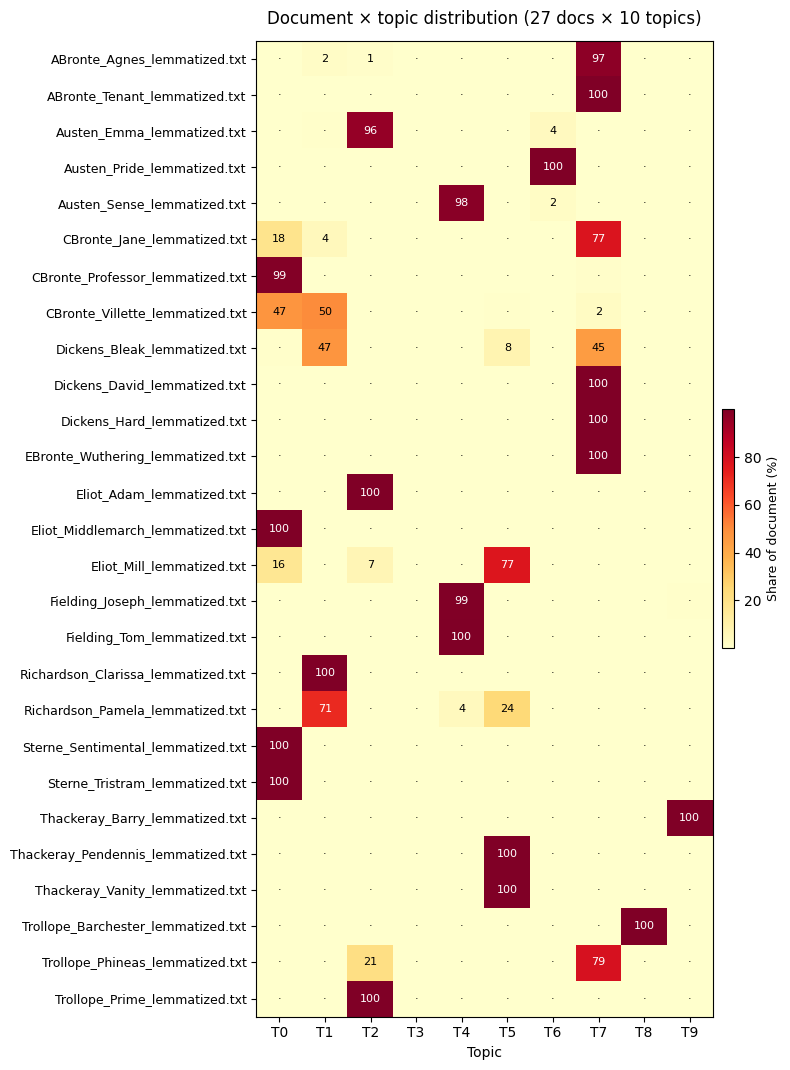

In [12]:
fig = document_topic_heatmap(lda, processed, dictionary)

### Reading the heatmap

- **A bright cell** = that topic dominates that document
- **A document dominated by one topic** = a focused, single-theme text
- **A document spread over many topics** = a varied, multi-theme text
- **Two documents with similar topic patterns** = they're "about the same thing" in the model's view

If you see the same author's books light up the same topics, the model has picked up on that author's recurring concerns. If a single topic stretches across many authors, it's a theme that crosses authorial boundaries.

## 7. Tuning: what if the topics look bad?

Bad topic models are usually fixable. Common diagnoses:

### Topics are too vague / contain function words

Stop word removal isn't aggressive enough. Add domain-specific stop words by editing the corpus before loading, or tighten `max_df` in `build_dictionary` (e.g. `max_df=0.5` to drop words appearing in >50% of documents).

### Two themes mash into one topic

Try **more topics**. If `num_topics=10` gives a "war-and-romance" topic, try `num_topics=15` — the model may split it.

### One theme splits into multiple topics

Try **fewer topics**. If multiple topics all look like sub-flavours of whaling, the model has over-fit and you should drop `num_topics`.

### Topics are dominated by proper names

Long novels mention character names hundreds of times. If you want themes rather than character profiles, add the names to your stop-word list, or use only common nouns (requires POS-tagging upstream).

### Results are unstable across random seeds

Try more `passes` (e.g. 30 or 50). If still unstable, your corpus may be too small or your `num_topics` too high relative to corpus size.

## 8. Where to go from here

- **Compare models with different `num_topics`** and pick by **coherence** (a metric that measures how interpretable topics are; gensim provides `CoherenceModel`).
- **Track topics over time** if your documents have dates — "how does the \"war\" topic rise and fall across the 19th century?"
- **Look at topics per author** to see authorial signatures.
- **Try other algorithms** — NMF (deterministic, fast, sometimes cleaner for small corpora), BERTopic (uses transformer embeddings, very different flavour).

Topic models give you a starting point, not a finished analysis. The numbers tell you where to look; the close reading still belongs to you.